In [2]:
# Core Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
import warnings
warnings.filterwarnings("ignore")
import shutil

# PyTorch Libraries
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense ,GlobalAveragePooling2D
import keras 

In [2]:
# Paths
source_dir = r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\image_dataset"

In [3]:
#data cleaning

valid_ext = ('.jpg', '.jpeg', '.png')

for root, dirs, files in os.walk(source_dir):
    for file in files:
        path = os.path.join(root, file)

        if not file.lower().endswith(valid_ext):
            os.remove(path)
            continue

        try:
            img = Image.open(path)
            img.verify()
        except:
            os.remove(path)

print("✅ Clean dataset done")

✅ Clean dataset done


In [4]:
#limiting the dataset with 500 images
limit_dataset = r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\image_dataset_limited"

LIMIT = 500

for class_name in os.listdir(source_dir):
    src_class_path = os.path.join(source_dir, class_name)
    dst_class_path = os.path.join(limit_dataset, class_name)
    
    os.makedirs(dst_class_path, exist_ok=True)
    
    images = os.listdir(src_class_path)
    
    # Select max 500 randomly
    selected = images if len(images) <= LIMIT else random.sample(images, LIMIT)
    
    for img in selected:
        shutil.copy(
            os.path.join(src_class_path, img),
            os.path.join(dst_class_path, img)
        )
    
    print(f"✅ {class_name}: {len(selected)} images copied")

✅ distractions: 500 images copied
✅ safe_driving: 500 images copied
✅ talking_phone: 500 images copied
✅ texting_phone: 500 images copied
✅ turning: 500 images copied


In [6]:
#split data to train, test, validation

# split dataset
split_data = r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\split_data"

SPLIT_RATIO = (0.7, 0.2, 0.1)  # train, val, test
random.seed(42)

# Create base folders
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(split_data, split), exist_ok=True)

# Loop through each class
for class_name in os.listdir(limit_dataset):
    class_path = os.path.join(limit_dataset, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    images = os.listdir(class_path)
    random.shuffle(images)
    
    total = len(images)
    train_end = int(SPLIT_RATIO[0] * total)
    val_end = train_end + int(SPLIT_RATIO[1] * total)
    
    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]
    
    # Copy images
    for split, split_imgs in zip(
        ['train', 'val', 'test'],
        [train_imgs, val_imgs, test_imgs]
    ):
        split_class_path = os.path.join(split_data, split, class_name)
        os.makedirs(split_class_path, exist_ok=True)
        
        for img in split_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_path, img)
            
            shutil.copy(src, dst)
    
    print(f"✅ {class_name} → Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")

✅ distractions → Train: 350, Val: 100, Test: 50
✅ safe_driving → Train: 350, Val: 100, Test: 50
✅ talking_phone → Train: 350, Val: 100, Test: 50
✅ texting_phone → Train: 350, Val: 100, Test: 50
✅ turning → Train: 350, Val: 100, Test: 50


In [7]:
train_dir = r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\split_data\train"
valid_dir = r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\split_data\val"
test_dir = r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\split_data\test"

In [8]:
#image preprocessing
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

valid_data = train_gen.flow_from_directory(valid_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)


Found 1750 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Found 250 images belonging to 5 classes.


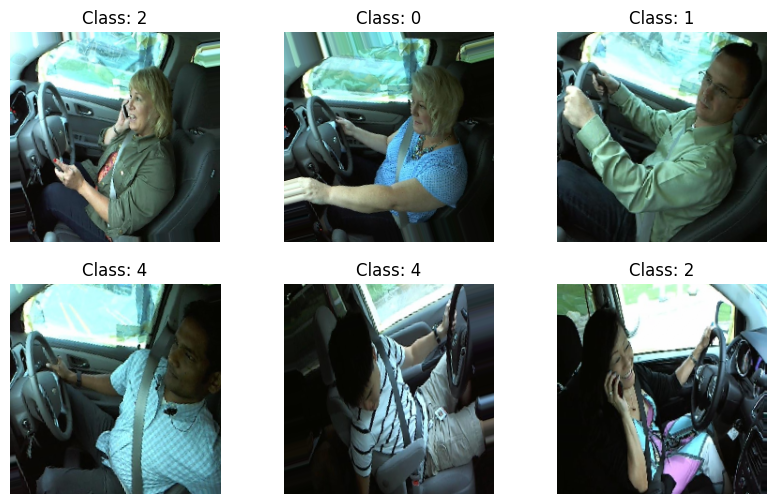

In [9]:
#view sample images
# Get one batch
images, labels = next(train_data)

plt.figure(figsize=(10,6))

for i in range(6):
    img = images[i]

    # Convert back from [-1,1] → [0,1]
    img = (img + 1) / 2

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Class: {labels[i].argmax()}")
    plt.axis('off')

plt.show()

In [10]:
#data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.Lambda(lambda x: tf.image.random_brightness(x, 0.2))
])


In [11]:
#CNN model - custom
cnn_model = keras.Sequential([data_augmentation, 
                
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(5, activation='softmax')  # 5 classes
])
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(patience=3)

history = cnn_model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15

110/110 ━━━━━━━━━━━━━━━━━━━━ 75s 659ms/step - accuracy: 0.1891 - loss: 1.6620 - val_accuracy: 0.2000 - val_loss: 1.6094
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 53s 480ms/step - accuracy: 0.1920 - loss: 1.6096 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 56s 510ms/step - accuracy: 0.1994 - loss: 1.6097 - val_accuracy: 0.2000 - val_loss: 1.6094
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 1033s 9s/step - accuracy: 0.1886 - loss: 1.6097 - val_accuracy: 0.1960 - val_loss: 1.6094
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 57s 513ms/step - accuracy: 0.1897 - loss: 1.6096 - val_accuracy: 0.2000 - val_loss: 1.6094
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 67s 609ms/step - accuracy: 0.1817 - loss: 1.6101 - val_accuracy: 0.2000 - val_loss: 1.6094
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2276s 21s/step - accuracy: 0.1909 - loss: 1.6098 - val_accuracy: 0.2000 - val_loss: 1.6094
Epoch 8/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 58s 504ms/step - accuracy: 0.1806 - loss: 1

In [12]:
loss, acc = cnn_model.evaluate(test_data)
print("Accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.2000 - loss: 1.6094
Accuracy: 0.20000000298023224


In [17]:
#save cnn model
cnn_model.save(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\saved_models\CNN_driver_behaviour.keras')

Accuracy is not as expected, thus training with mobilenet pretrained CNN model
Shifted to google collab, due to time consumption

In [6]:
# Load in your training environment
model = tf.keras.models.load_model(r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\saved_models\CNN_driver_behaviour.keras", safe_mode=False, compile=False)

# Save properly
model.save(r"C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\saved_models\CNN_driver behaviour.h5")